In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from src.processing import load_and_clean_data
from src.features import generate_features
from src.features_rv import generate_rv_features
from src.pooling import pool_boj_data
from src.pooling_butterfly import pool_butterfly_data
from src.modeling import walk_forward_validation

START_DATE  = '2024-01-01'
FLY_COLOR   = '#ff7f0e'
OUT_COLOR   = '#1f77b4'
SIGNAL_DAYS = 30   # シグナル履歴の表示日数

FLY_SHORT = {2: 'B2', 3: 'B3', 4: 'B4', 5: 'B5', 6: 'B6', 7: 'B7'}

In [2]:
# ── データ読み込み・プーリング ──────────────────────────────────
print('Loading data...')
df_raw = load_and_clean_data('../data/BOJ_data.xlsx', '../data/BOJ_meeting_history.csv')

df_fly = pool_butterfly_data(generate_rv_features(df_raw))
df_out = pool_boj_data(generate_features(df_raw))

print(f'Data through : {df_raw["Date"].max().date()}')
print(f'Butterfly    : {df_fly.shape}  Outright: {df_out.shape}')

Loading data...


Data through : 2026-03-13
Butterfly    : (27918, 36)  Outright: (50639, 53)


In [3]:
# ── Walk-Forward Validation ────────────────────────────────────
print('Running Butterfly walk-forward...')
res_fly_3d, model_fly_3d, *_ = walk_forward_validation(
    df_fly, 'Target_3d_norm', START_DATE, return_model=True)
res_fly_5d, model_fly_5d, *_ = walk_forward_validation(
    df_fly, 'Target_5d_norm', START_DATE, return_model=True)

print('Running Outright walk-forward...')
res_out_3d, model_out_3d, *_ = walk_forward_validation(
    df_out, 'Target_3d_norm', START_DATE, return_model=True)
res_out_5d, model_out_5d, *_ = walk_forward_validation(
    df_out, 'Target_5d_norm', START_DATE, return_model=True)

# 逆正規化用 std を結合（各銘柄の Target_std は日付によらず一定だが安全のため Date も key に）
std_fly = (df_fly[['Date', 'Meeting_Index', 'Target_3d_std', 'Target_5d_std']]
           .drop_duplicates())
std_out = (df_out[['Date', 'Meeting_Index', 'Target_3d_std', 'Target_5d_std']]
           .drop_duplicates())

res_fly_3d = res_fly_3d.merge(std_fly, on=['Date', 'Meeting_Index'], how='left')
res_fly_5d = res_fly_5d.merge(std_fly, on=['Date', 'Meeting_Index'], how='left')
res_out_3d = res_out_3d.merge(std_out, on=['Date', 'Meeting_Index'], how='left')
res_out_5d = res_out_5d.merge(std_out, on=['Date', 'Meeting_Index'], how='left')

print(f'OOS period   : {res_fly_3d["Date"].min().date()} → {res_fly_3d["Date"].max().date()}')

Running Butterfly walk-forward...


Running Outright walk-forward...


OOS period   : 2024-01-04 → 2026-03-10


In [4]:
# ── シグナル抽出 ──────────────────────────────────────────────

# シグナル基準日 = 3d・5d OOS の両方に共通する最新日
# （5d は Target_5d が末尾 5 日分欠けるため 3d より日付が少ない）
_fly_common = set(res_fly_3d['Date'].unique()) & set(res_fly_5d['Date'].unique())
_out_common = set(res_out_3d['Date'].unique()) & set(res_out_5d['Date'].unique())
SIGNAL_DATE = max(_fly_common & _out_common)

# ── Butterfly シグナル ──
def _get_fly_signal(res_3d, res_5d, date):
    r3 = res_3d[res_3d['Date'] == date][['Meeting_Index', 'Pred', 'Target_3d_std']].copy()
    r5 = res_5d[res_5d['Date'] == date][['Meeting_Index', 'Pred', 'Target_5d_std']].copy()
    r3['Pred_3d_bp'] = r3['Pred'] * r3['Target_3d_std'] * 100   # % → bp
    r5['Pred_5d_bp'] = r5['Pred'] * r5['Target_5d_std'] * 100
    sig = (r3[['Meeting_Index', 'Pred', 'Pred_3d_bp']]
           .merge(r5[['Meeting_Index', 'Pred_5d_bp']], on='Meeting_Index')
           .rename(columns={'Pred': 'Score_3d'}))
    # 現在のバタフライ水準（bp換算）
    lvl = (df_fly[df_fly['Date'] == date]
           [['Meeting_Index', 'Fly_Level']].drop_duplicates())
    lvl['Fly_Level_bp'] = lvl['Fly_Level'] * 100
    sig = sig.merge(lvl[['Meeting_Index', 'Fly_Level_bp']], on='Meeting_Index', how='left')
    sig['Label'] = sig['Meeting_Index'].map(FLY_SHORT)
    return sig.sort_values('Score_3d', ascending=False).reset_index(drop=True)

# ── M4 アウトライトシグナル ──
def _get_m4_signal(res_3d, res_5d, date):
    r3 = res_3d[(res_3d['Date'] == date) & (res_3d['Meeting_Index'] == 4)]
    r5 = res_5d[(res_5d['Date'] == date) & (res_5d['Meeting_Index'] == 4)]
    if r3.empty or r5.empty:
        return None
    # M4 のスプレッド（bp）は df_out の M4_spread 列から取得
    m4_row = df_out[(df_out['Date'] == date) & (df_out['Meeting_Index'] == 4)]
    m4_spread_bp = float(m4_row['M4_spread'].values[0]) * 100 if not m4_row.empty else np.nan
    policy_bp    = float(df_raw[df_raw['Date'] == date]['Actual_Policy_Rate'].values[0]) * 100
    std3 = float(r3['Target_3d_std'].values[0])
    std5 = float(r5['Target_5d_std'].values[0])
    return {
        'M4_abs_bp'    : m4_spread_bp + policy_bp,
        'M4_spread_bp' : m4_spread_bp,
        'Pred_3d_bp'   : float(r3['Pred'].values[0]) * std3 * 100,
        'Pred_5d_bp'   : float(r5['Pred'].values[0]) * std5 * 100,
    }

fly_sig = _get_fly_signal(res_fly_3d, res_fly_5d, SIGNAL_DATE)
m4_sig  = _get_m4_signal(res_out_3d, res_out_5d, SIGNAL_DATE)

print(f'Signal date: {SIGNAL_DATE.date()}')
print(fly_sig[['Label', 'Fly_Level_bp', 'Pred_3d_bp', 'Pred_5d_bp']].to_string(index=False))
print()
print('M4:', m4_sig)

Signal date: 2026-03-06
Label  Fly_Level_bp  Pred_3d_bp  Pred_5d_bp
   B5        -2.250    0.640632    0.875690
   B7        -1.500    0.502007    0.538418
   B4        -0.375    0.188719    0.194149
   B3         1.000   -0.038877    0.206717
   B2         8.375   -0.642835   -1.634377
   B6         2.000   -0.807216   -0.899340

M4: {'M4_abs_bp': 99.75, 'M4_spread_bp': 24.750000000000007, 'Pred_3d_bp': -1.669771598585136, 'Pred_5d_bp': 0.2553683727737745}


In [5]:
# ── コンソール出力：トレードシグナルテーブル ───────────────────

print(f"\n{'='*62}")
print(f"  BOJ OIS Trade Signal   {SIGNAL_DATE.date()}")
print(f"{'='*62}")

print("\n【 Butterfly シグナル 】")
print("  (Score_3d 降順 = ランク高が 3d ロング候補)")
print()
hdr = f"  {'Rank':>4}  {'Symbol':<5}  {'Level(bp)':>9}  {'Pred_3d(bp)':>11}  {'Pred_5d(bp)':>11}  Dir"
print(hdr)
print('  ' + '-' * (len(hdr) - 2))
for rank, row in enumerate(fly_sig.itertuples(), 1):
    lvl = f"{row.Fly_Level_bp:+.3f}" if not pd.isna(row.Fly_Level_bp) else '  N/A '
    d   = '▲' if row.Pred_3d_bp > 0 else '▼'
    print(f"  {rank:>4}  {row.Label:<5}  {lvl:>9}  {row.Pred_3d_bp:>+10.3f}  {row.Pred_5d_bp:>+10.3f}  {d}")

print("\n【 M4 アウトライトシグナル（方向性参考）】")
if m4_sig:
    d3 = '▲ UP  ' if m4_sig['Pred_3d_bp'] > 0 else '▼ DOWN'
    d5 = '▲ UP  ' if m4_sig['Pred_5d_bp'] > 0 else '▼ DOWN'
    print(f"  M4 水準             : {m4_sig['M4_abs_bp']:.1f} bp")
    print(f"  M4 スプレッド       : {m4_sig['M4_spread_bp']:+.1f} bp  (vs 政策金利)")
    print(f"  予測 3d 変化        : {m4_sig['Pred_3d_bp']:+.3f} bp  {d3}")
    print(f"  予測 5d 変化        : {m4_sig['Pred_5d_bp']:+.3f} bp  {d5}")
else:
    print('  M4 signal not available for this date (post-MPM period excluded).')

print(f"\n{'='*62}")


  BOJ OIS Trade Signal   2026-03-06

【 Butterfly シグナル 】
  (Score_3d 降順 = ランク高が 3d ロング候補)

  Rank  Symbol  Level(bp)  Pred_3d(bp)  Pred_5d(bp)  Dir
  ------------------------------------------------------
     1  B5        -2.250      +0.641      +0.876  ▲
     2  B7        -1.500      +0.502      +0.538  ▲
     3  B4        -0.375      +0.189      +0.194  ▲
     4  B3        +1.000      -0.039      +0.207  ▼
     5  B2        +8.375      -0.643      -1.634  ▼
     6  B6        +2.000      -0.807      -0.899  ▼

【 M4 アウトライトシグナル（方向性参考）】
  M4 水準             : 99.8 bp
  M4 スプレッド       : +24.8 bp  (vs 政策金利)
  予測 3d 変化        : -1.670 bp  ▼ DOWN
  予測 5d 変化        : +0.255 bp  ▲ UP  



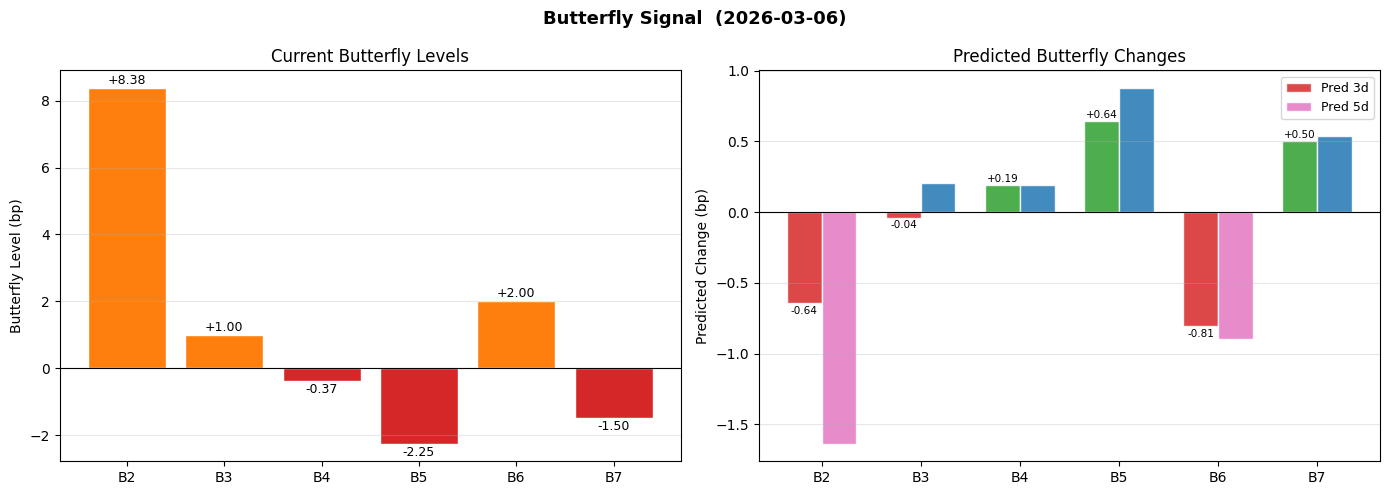

In [6]:
# ── Figure 1: バタフライ水準 + 予測変化量 ─────────────────────

# Meeting_Index 昇順で整列して描画
fly_plot = fly_sig.sort_values('Meeting_Index').reset_index(drop=True)
labels   = fly_plot['Label'].tolist()
levels   = fly_plot['Fly_Level_bp'].tolist()
pred_3d  = fly_plot['Pred_3d_bp'].tolist()
pred_5d  = fly_plot['Pred_5d_bp'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Butterfly Signal  ({SIGNAL_DATE.date()})', fontsize=13, fontweight='bold')

# 左: 現在水準
ax = axes[0]
colors = ['#d62728' if v < 0 else FLY_COLOR for v in levels]
ax.bar(labels, levels, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Butterfly Level (bp)')
ax.set_title('Current Butterfly Levels')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(levels):
    if not np.isnan(v):
        ax.text(i, v + (0.03 if v >= 0 else -0.06),
                f'{v:+.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=9)

# 右: 予測変化量（3d・5d 並列棒）
ax = axes[1]
x, w = np.arange(len(labels)), 0.35
ax.bar(x - w/2, pred_3d, width=w, label='Pred 3d',
       color=['#2ca02c' if v >= 0 else '#d62728' for v in pred_3d],
       alpha=0.85, edgecolor='white')
ax.bar(x + w/2, pred_5d, width=w, label='Pred 5d',
       color=['#1f77b4' if v >= 0 else '#e377c2' for v in pred_5d],
       alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Predicted Change (bp)')
ax.set_title('Predicted Butterfly Changes')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(pred_3d):
    ax.text(i - w/2, v + (0.01 if v >= 0 else -0.02),
            f'{v:+.2f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=7.5)

plt.tight_layout()
plt.savefig('../outputs/signal_butterfly.png', dpi=150, bbox_inches='tight')
plt.show()

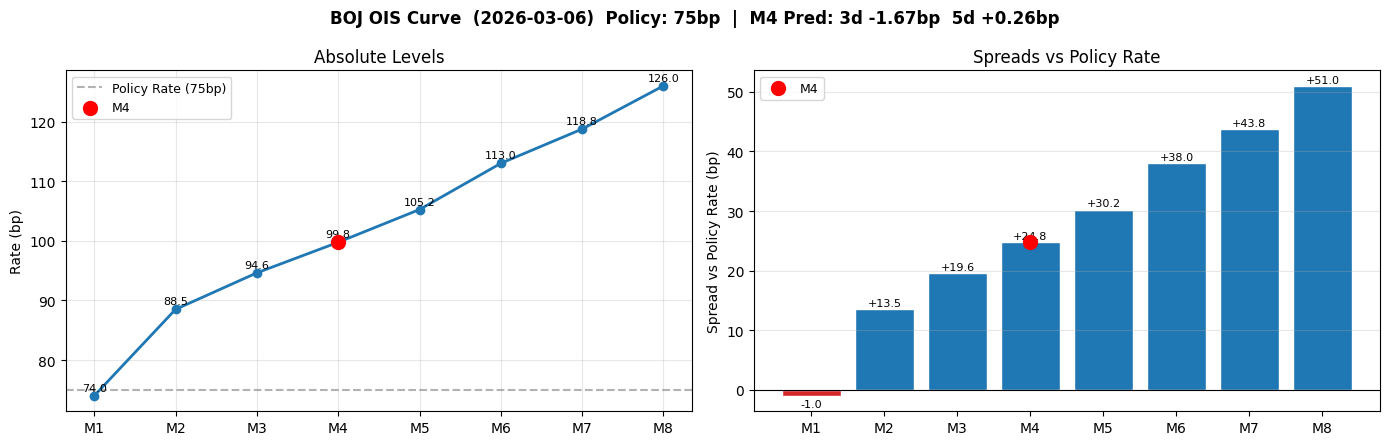

In [7]:
# ── Figure 2: 現在の金利カーブ（M1〜M8）+ M4 ハイライト ────────

raw_row    = df_raw[df_raw['Date'] == SIGNAL_DATE].iloc[0]
rate_cols  = [f'M{n}' for n in range(1, 9)]
rate_vals  = [raw_row[c] * 100 for c in rate_cols]   # % → bp
policy_bp  = raw_row['Actual_Policy_Rate'] * 100
spread_vals= [v - policy_bp for v in rate_vals]

m4_dir_str = ''
if m4_sig:
    m4_dir_str = (f"  |  M4 Pred: 3d {m4_sig['Pred_3d_bp']:+.2f}bp  "
                  f"5d {m4_sig['Pred_5d_bp']:+.2f}bp")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(
    f'BOJ OIS Curve  ({SIGNAL_DATE.date()})  Policy: {policy_bp:.0f}bp{m4_dir_str}',
    fontsize=12, fontweight='bold')

# 左: 絶対水準
ax = axes[0]
ax.plot(rate_cols, rate_vals, marker='o', color=OUT_COLOR, linewidth=2, zorder=3)
ax.axhline(policy_bp, color='gray', linestyle='--', alpha=0.6,
           label=f'Policy Rate ({policy_bp:.0f}bp)')
ax.scatter(['M4'], [rate_vals[3]], color='red', s=100, zorder=5, label='M4')
ax.set_ylabel('Rate (bp)')
ax.set_title('Absolute Levels')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
for i, v in enumerate(rate_vals):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# 右: スプレッド（vs 政策金利）
ax = axes[1]
ax.bar(rate_cols, spread_vals,
       color=[OUT_COLOR if v >= 0 else '#d62728' for v in spread_vals],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.scatter(['M4'], [spread_vals[3]], color='red', s=100, zorder=5, label='M4')
ax.set_ylabel('Spread vs Policy Rate (bp)')
ax.set_title('Spreads vs Policy Rate')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(spread_vals):
    ax.text(i, v + (0.2 if v >= 0 else -0.5), f'{v:+.1f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/signal_curve.png', dpi=150, bbox_inches='tight')
plt.show()

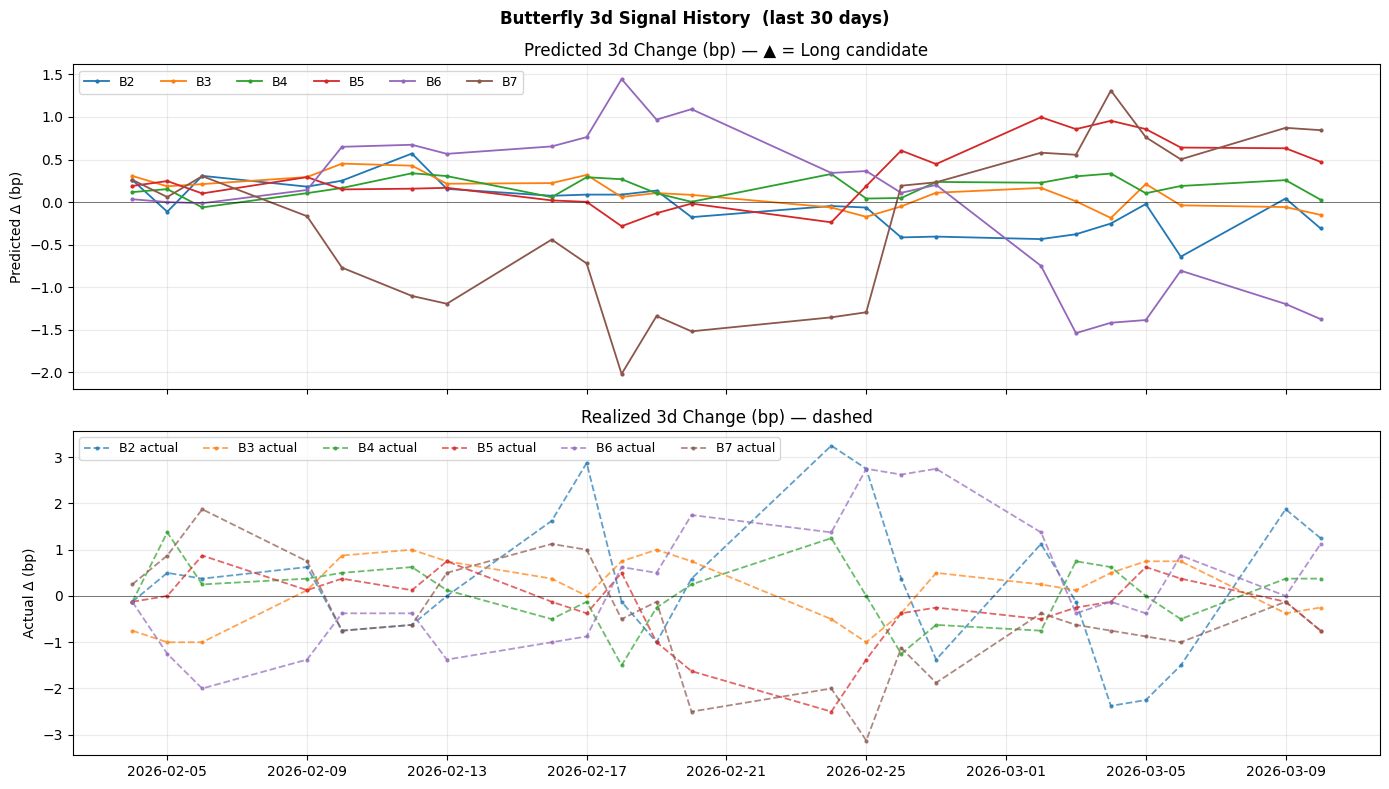

In [8]:
# ── Figure 3: シグナル履歴（直近 SIGNAL_DAYS 日）─────────────────

cutoff  = SIGNAL_DATE - pd.Timedelta(days=SIGNAL_DAYS)
hist_3d = res_fly_3d[res_fly_3d['Date'] >= cutoff].copy()
hist_3d['Pred_bp'] = hist_3d['Pred'] * hist_3d['Target_3d_std'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f'Butterfly 3d Signal History  (last {SIGNAL_DAYS} days)',
    fontsize=12, fontweight='bold')

cmap      = plt.cm.tab10
fly_insts = sorted(hist_3d['Meeting_Index'].unique())

# 上段: 予測変化量（bp）
ax = axes[0]
for i, inst in enumerate(fly_insts):
    sub = hist_3d[hist_3d['Meeting_Index'] == inst].sort_values('Date')
    ax.plot(sub['Date'], sub['Pred_bp'], marker='.', markersize=4,
            label=FLY_SHORT[inst], color=cmap(i), linewidth=1.3)
ax.axhline(0, color='black', linewidth=0.7, alpha=0.5)
ax.set_ylabel('Predicted Δ (bp)')
ax.set_title('Predicted 3d Change (bp) — ▲ = Long candidate')
ax.legend(ncol=6, fontsize=9)
ax.grid(True, alpha=0.25)

# 下段: 実測値との比較
for i, inst in enumerate(fly_insts):
    sub = hist_3d[hist_3d['Meeting_Index'] == inst].sort_values('Date')
    actual_bp = sub['Actual'] * sub['Target_3d_std'] * 100
    axes[1].plot(sub['Date'], actual_bp, marker='.', markersize=4,
                 label=f'{FLY_SHORT[inst]} actual', color=cmap(i),
                 linewidth=1.3, linestyle='--', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.7, alpha=0.5)
axes[1].set_ylabel('Actual Δ (bp)')
axes[1].set_title('Realized 3d Change (bp) — dashed')
axes[1].legend(ncol=6, fontsize=9)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('../outputs/signal_history.png', dpi=150, bbox_inches='tight')
plt.show()

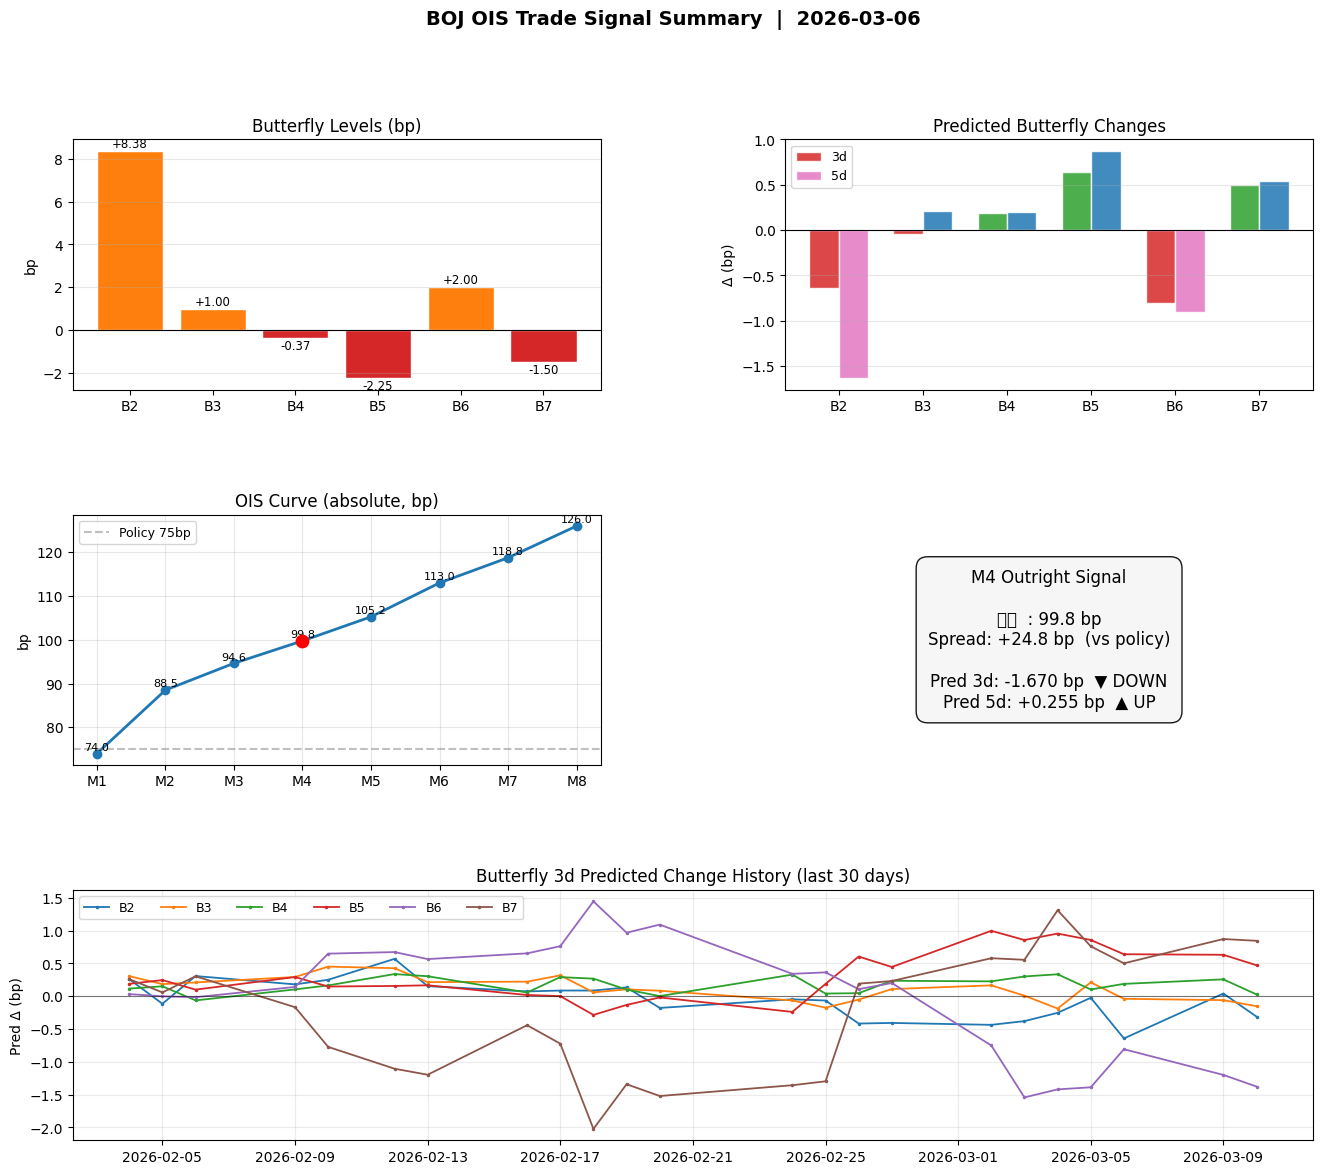

Saved: outputs/trade_signal_summary.png


In [9]:
# ── Figure 4: 1ページ完結サマリー ─────────────────────────────

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)
cmap = plt.cm.tab10

fig.suptitle(
    f'BOJ OIS Trade Signal Summary  |  {SIGNAL_DATE.date()}',
    fontsize=14, fontweight='bold')

# (0,0) バタフライ現在水準
ax = fig.add_subplot(gs[0, 0])
ax.bar(labels, levels,
       color=['#d62728' if v < 0 else FLY_COLOR for v in levels],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('bp'); ax.set_title('Butterfly Levels (bp)')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(levels):
    if not np.isnan(v):
        ax.text(i, v + (0.03 if v >= 0 else -0.05), f'{v:+.2f}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=8.5)

# (0,1) バタフライ予測変化
ax = fig.add_subplot(gs[0, 1])
ax.bar(np.arange(len(labels)) - w/2, pred_3d, width=w, label='3d',
       color=['#2ca02c' if v >= 0 else '#d62728' for v in pred_3d],
       alpha=0.85, edgecolor='white')
ax.bar(np.arange(len(labels)) + w/2, pred_5d, width=w, label='5d',
       color=['#1f77b4' if v >= 0 else '#e377c2' for v in pred_5d],
       alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel('Δ (bp)'); ax.set_title('Predicted Butterfly Changes')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# (1,0) カーブ絶対水準
ax = fig.add_subplot(gs[1, 0])
ax.plot(rate_cols, rate_vals, marker='o', color=OUT_COLOR, linewidth=2)
ax.axhline(policy_bp, color='gray', linestyle='--', alpha=0.5,
           label=f'Policy {policy_bp:.0f}bp')
ax.scatter(['M4'], [rate_vals[3]], color='red', s=80, zorder=5)
ax.set_ylabel('bp'); ax.set_title('OIS Curve (absolute, bp)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
for i, v in enumerate(rate_vals):
    ax.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# (1,1) M4 シグナルテキスト
ax = fig.add_subplot(gs[1, 1])
ax.axis('off')
if m4_sig:
    txt = (
        f"M4 Outright Signal\n\n"
        f"水準  : {m4_sig['M4_abs_bp']:.1f} bp\n"
        f"Spread: {m4_sig['M4_spread_bp']:+.1f} bp  (vs policy)\n\n"
        f"Pred 3d: {m4_sig['Pred_3d_bp']:+.3f} bp  "
        f"{'▲ UP' if m4_sig['Pred_3d_bp'] > 0 else '▼ DOWN'}\n"
        f"Pred 5d: {m4_sig['Pred_5d_bp']:+.3f} bp  "
        f"{'▲ UP' if m4_sig['Pred_5d_bp'] > 0 else '▼ DOWN'}"
    )
else:
    txt = 'M4 signal\nnot available\n(post-MPM period)'
ax.text(0.5, 0.5, txt, ha='center', va='center', fontsize=12,
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#f5f5f5', alpha=0.9))

# (2,:) シグナル履歴
ax = fig.add_subplot(gs[2, :])
fly_insts = sorted(hist_3d['Meeting_Index'].unique())
for i, inst in enumerate(fly_insts):
    sub = hist_3d[hist_3d['Meeting_Index'] == inst].sort_values('Date')
    ax.plot(sub['Date'], sub['Pred_bp'], marker='.', markersize=3,
            label=FLY_SHORT[inst], color=cmap(i), linewidth=1.3)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Pred Δ (bp)')
ax.set_title(f'Butterfly 3d Predicted Change History (last {SIGNAL_DAYS} days)')
ax.legend(ncol=6, fontsize=9)
ax.grid(True, alpha=0.25)

plt.savefig('../outputs/trade_signal_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/trade_signal_summary.png')